PARAMETER FITTING IMPLEMENTATION

# Preliminaries

In [1]:
# Python packages used in this chapter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import urllib.request # use this library to download file from GitHub
try:
    import tellurium as te
except:
    !pip install -q tellurium
    import tellurium as te
import seaborn as sns

# Simple model

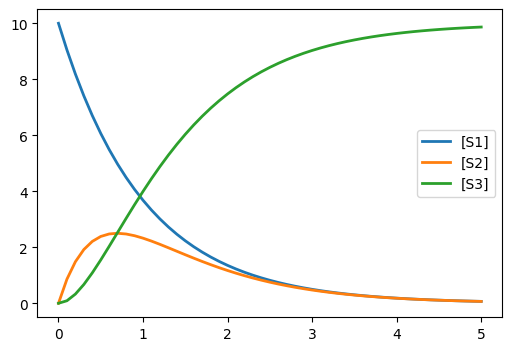

In [2]:
MODEL = """
S1 -> S2; k1*S1
S2 -> S3; k2*S2

S1 = 10
S2 = 0
k1 = 1
k2 = 2
"""
rr = te.loada(MODEL)
rr.simulate()
rr.plot()

## Synthetic Observational Data

In [3]:
# Author: Gemini (with some edits)
def simulate_and_add_noise(antimony_model: str, std_dev: float) -> pd.DataFrame:
    """
    Simulates an Antimony model and adds Gaussian noise in log space to the output.

    Args:
        antimony_model (str): The Antimony model string.
        std_dev (float): The standard deviation of the Gaussian noise.

    Returns:
        pandas.DataFrame: A DataFrame containing the simulation results with added noise.
    """
    # Load and simulate the model
    rr = te.loada(antimony_model)
    simulation_results = rr.simulate()

    # Add Gaussian noise in log space, avoiding log(0)
    # Add a small epsilon to handle potential zero values before taking log
    epsilon = 1e-9
    log_simulation_results = np.log(simulation_results + epsilon)
    noisy_log_results = log_simulation_results + np.random.normal(0, std_dev, size=simulation_results.shape)

    # Convert back from log space
    noisy_results = np.exp(noisy_log_results)


    return pd.DataFrame(noisy_results, columns=simulation_results.colnames)

# Test the function with a sample model and noise level
noisy_simulation_df = simulate_and_add_noise(MODEL, std_dev=0.1)
assert(len(noisy_simulation_df) > 0)
print("OK!")

OK!


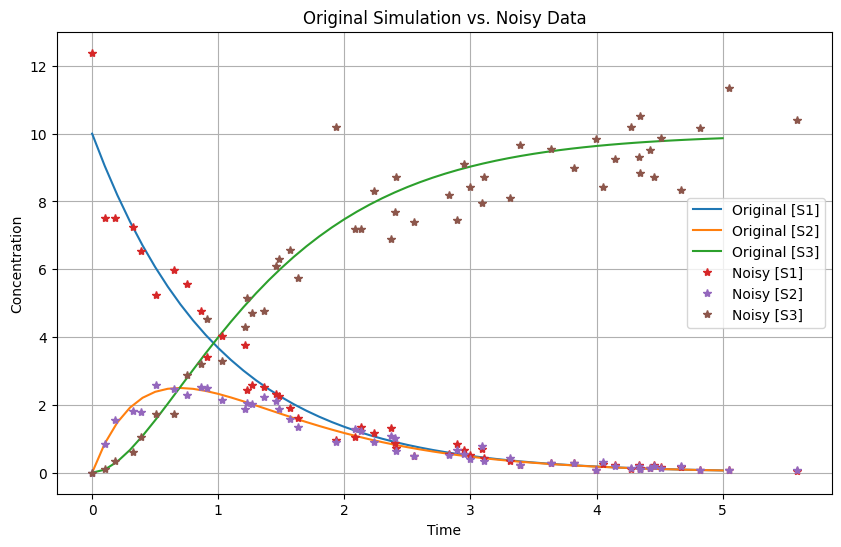

In [4]:
# Author: Gemini
# Simulate the original model without noise
rr_original = te.loada(MODEL)
original_simulation_results = rr_original.simulate()
original_df = pd.DataFrame(original_simulation_results, columns=original_simulation_results.colnames)

# Plot the original and noisy data
plt.figure(figsize=(10, 6))

# Plot original concentrations as lines
for col in original_df.columns[1:]:  # Exclude 'time' column
    plt.plot(original_df['time'], original_df[col], label=f'Original {col}')

# Plot noisy data as asterisks
for col in noisy_simulation_df.columns[1:]:  # Exclude 'time' column
    plt.plot(noisy_simulation_df['time'], noisy_simulation_df[col], '*', label=f'Noisy {col}')

plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Original Simulation vs. Noisy Data')
plt.legend()
plt.grid(True)
plt.show()

# Pseudo Code

def estimateParameters(model_ant, parameter_names, observational_data) -> parameter_dct:
    parameter_dct = {}
    
    do until good estimate or exceed runtime limits
        settings = new assignment of values to parameter_names
        simulationResults = run model_ant using settings
        residuals = observedValues - simulationResults
        if the sum of squares of residuals is smaller than previous settings
            parameter_dct is a dictionary of parameter names and the values in settings
        if residuals are very small
            return parameter_dct


# Gemini implementation